# Pass Decision Analysis Using Markov Decision Processes

**Project**: Final Project - Deep Learning & AI in Sport  
**Author**: [Your Name]  
**Date**: November 2025  
**Deadline**: November 13, 2025

---

## 🎯 Project Overview

This notebook analyzes decision-making in soccer using Markov Decision Processes (MDP), extending the methodology from Van Roy et al.'s "Leaving Goals on the Pitch" paper from shooting decisions to **pass type selection and ball carrying**.

### Research Questions

1. **Optimal Action Selection**: For each zone, which action (pass type, shot, or carry) maximizes goal probability?

2. **Sequential Action Analysis**: Do multiple short passes yield higher goal probability than carries or long balls?

3. **Counterfactual Policy Analysis**: How would expected goals change if teams altered their action policies?

4. **Quality-Quantity Trade-offs**: When action frequency increases, how does success rate decline?

---

## 📊 Methodology

- **State Space**: 22×34 field grid = 748 states + 3 absorbing states (goal, no_goal, loss_possession)
- **Action Space**: 10 actions (8 pass types + shoot + carry)
  - Pass types: short/medium × backward/lateral/forward + long × backward/forward
  - Pass thresholds: short ≤10m, medium 10-25m, long >25m
  - Direction thresholds: forward/backward >5m, lateral ≤5m
  - Shoot: attempted shots on goal
  - Carry: dribbling with the ball
- **Action Masking**: 
  - Shooting disabled >30m from goal (reduces sparsity)
  - Edge constraints for forward/backward passes
- **Data**: Full Premier League 2024 season (~460K actions: 268K passes, 8.7K shots, 184K carries)
- **Analysis**: Fundamental matrix, probabilistic verification, counterfactual scenarios

---

## 1. Setup & Imports

Import required libraries and custom modules.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Reload modules to pick up changes
import importlib
import sys

# Custom modules
from src import data_processing as dp
from src import state_action as sa
from src import mdp
from src import success_modeling as sm
from src import analysis as an
from src import visualization as viz

# Reload to pick up code changes
importlib.reload(dp)
importlib.reload(sa)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All imports successful!")
print(f"Working directory: {Path.cwd()}")
print("✓ Modules reloaded to pick up latest changes")

✓ All imports successful!
Working directory: /home/macaco3001/Projectos/Twelve/twelve-deep-learning/Project
✓ Modules reloaded to pick up latest changes


## 2. Data Loading & Exploration

Load Premier League event data and explore basic statistics.

In [2]:
# Load Premier League 2024 event data
print("Loading Premier League 2024 events...")
events = dp.load_premier_league_events()

print(f"\n{'='*60}")
print(f"DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Total events loaded: {len(events):,}")
print(f"\nEvent types:")
print(events['event_type'].value_counts())

# Basic temporal information
if 'timestamp' in events.columns:
    print(f"\nTemporal range: {events['timestamp'].min()} to {events['timestamp'].max()}")
    
print(f"\nUnique matches: {events['match_id'].nunique()}")
print(f"{'='*60}")

Loading Premier League 2024 events...
Found 378 matches in /home/macaco3001/Projectos/Twelve/twelve-deep-learning/PremierLeague_data/2024/dynamic
  Loaded 50/378 matches...
  Loaded 50/378 matches...
  Loaded 100/378 matches...
  Loaded 100/378 matches...
  Loaded 150/378 matches...
  Loaded 150/378 matches...
  Loaded 200/378 matches...
  Loaded 200/378 matches...
  Loaded 250/378 matches...
  Loaded 250/378 matches...
  Loaded 300/378 matches...
  Loaded 300/378 matches...
  Loaded 350/378 matches...
  Loaded 350/378 matches...
✅ Loaded 1,811,078 total events from 378 matches
   Event types: 4
   Date range: 1650385 to 2018580

DATASET OVERVIEW
Total events loaded: 1,811,078

Event types:
event_type
passing_option        939059
player_possession     362853
on_ball_engagement    326100
off_ball_run          183066
Name: count, dtype: int64

Unique matches: 378
✅ Loaded 1,811,078 total events from 378 matches
   Event types: 4
   Date range: 1650385 to 2018580

DATASET OVERVIEW
Total e

### 2.1 Extract and Filter Pass Events

Extract player possession events (passes) and examine initial statistics.

In [3]:
# Extract pass events (excludes clearances, includes only passes)
print("Extracting pass events...")
passes_raw = dp.extract_pass_events(events)

print(f"\n{'='*60}")
print(f"PASS EVENT EXTRACTION")
print(f"{'='*60}")
print(f"Total passes extracted: {len(passes_raw):,}")

# Pass outcome distribution
print(f"\nPass outcomes:")
if 'success' in passes_raw.columns:
    success_count = passes_raw['success'].sum()
    total = len(passes_raw)
    print(f"  Successful: {success_count:,} ({success_count/total*100:.2f}%)")
    print(f"  Unsuccessful: {total - success_count:,} ({(total-success_count)/total*100:.2f}%)")

print(f"{'='*60}")

Extracting pass events...
Extracting pass events from 1,811,078 total events...
  Found 362,853 player_possession events
  Removing 0 events with missing coordinates
  Found 362,853 player_possession events
  Removing 0 events with missing coordinates
  Removing 3,733 clearances
  Removing 3,733 clearances
  Pass outcomes:
    Successful:   273,338 (76.1%)
    Unsuccessful: 55,412 (15.4%)
    Offside:         966 ( 0.3%)
✅ Extracted 359,120 pass events

PASS EVENT EXTRACTION
Total passes extracted: 359,120

Pass outcomes:
  Successful: 273,338 (76.11%)
  Unsuccessful: 85,782 (23.89%)
  Pass outcomes:
    Successful:   273,338 (76.1%)
    Unsuccessful: 55,412 (15.4%)
    Offside:         966 ( 0.3%)
✅ Extracted 359,120 pass events

PASS EVENT EXTRACTION
Total passes extracted: 359,120

Pass outcomes:
  Successful: 273,338 (76.11%)
  Unsuccessful: 85,782 (23.89%)


In [4]:
# Extract shot events (action=8 in our action space)
print("Extracting shot events...")
shots_raw = dp.extract_shot_events(events)

print(f"\n{'='*60}")
print(f"SHOT EVENT EXTRACTION")
print(f"{'='*60}")
print(f"Total shots extracted: {len(shots_raw):,}")

# Shot outcome distribution
print(f"\nShot outcomes:")
if 'success' in shots_raw.columns:
    goals = shots_raw['success'].sum()
    total = len(shots_raw)
    print(f"  Goals:    {goals:,} ({goals/total*100:.2f}%)")
    print(f"  No goals: {total - goals:,} ({(total-goals)/total*100:.2f}%)")

print(f"{'='*60}")

Extracting shot events...
Extracting shot events from 1,811,078 total events...
  Found 8,677 shot events
  Shot outcomes:
    Goals:      1,071 (12.3%)
    No goals:   7,606 (87.7%)
✅ Extracted 8,677 shot events

SHOT EVENT EXTRACTION
Total shots extracted: 8,677

Shot outcomes:
  Goals:    1,071 (12.34%)
  No goals: 7,606 (87.66%)
  Found 8,677 shot events
  Shot outcomes:
    Goals:      1,071 (12.3%)
    No goals:   7,606 (87.7%)
✅ Extracted 8,677 shot events

SHOT EVENT EXTRACTION
Total shots extracted: 8,677

Shot outcomes:
  Goals:    1,071 (12.34%)
  No goals: 7,606 (87.66%)


In [5]:
# Extract carry events (action=9 in our action space)
print("Extracting carry events...")
carries_raw = dp.extract_carry_events(events)

print(f"\n{'='*60}")
print(f"CARRY EVENT EXTRACTION")
print(f"{'='*60}")
print(f"Total carries extracted: {len(carries_raw):,}")

# Carry outcome distribution
print(f"\nCarry outcomes:")
if 'success' in carries_raw.columns:
    successful = carries_raw['success'].sum()
    total = len(carries_raw)
    print(f"  Successful:   {successful:,} ({successful/total*100:.2f}%)")
    print(f"  Unsuccessful: {total - successful:,} ({(total-successful)/total*100:.2f}%)")

# Distance statistics
if 'distance_covered' in carries_raw.columns:
    print(f"\nDistance statistics:")
    print(f"  Mean:   {carries_raw['distance_covered'].mean():.2f}m")
    print(f"  Median: {carries_raw['distance_covered'].median():.2f}m")
    print(f"  Max:    {carries_raw['distance_covered'].max():.2f}m")

print(f"{'='*60}")

Extracting carry events...
Extracting carry events from 1,811,078 total events...
  Found 184,080 carry events
  Carry outcomes:
    Successful (ended in pass/shot): 168,618 (91.6%)
    Failed (possession lost):        15,462 ( 8.4%)
✅ Extracted 184,080 carry events

CARRY EVENT EXTRACTION
Total carries extracted: 184,080

Carry outcomes:
  Successful:   168,618 (91.60%)
  Unsuccessful: 15,462 (8.40%)

Distance statistics:
  Mean:   8.53m
  Median: 5.77m
  Max:    89.40m
  Found 184,080 carry events
  Carry outcomes:
    Successful (ended in pass/shot): 168,618 (91.6%)
    Failed (possession lost):        15,462 ( 8.4%)
✅ Extracted 184,080 carry events

CARRY EVENT EXTRACTION
Total carries extracted: 184,080

Carry outcomes:
  Successful:   168,618 (91.60%)
  Unsuccessful: 15,462 (8.40%)

Distance statistics:
  Mean:   8.53m
  Median: 5.77m
  Max:    89.40m


In [6]:
# Combine passes, shots, and carries into single DataFrame
print("Combining passes, shots, and carries...")
actions_raw = dp.combine_passes_shots_carries(passes_raw, shots_raw, carries_raw)

print(f"\n{'='*60}")
print(f"COMBINED ACTIONS")
print(f"{'='*60}")
print(f"Total actions: {len(actions_raw):,}")
print(f"  - Passes:  {(actions_raw['action_type']=='pass').sum():,}")
print(f"  - Shots:   {(actions_raw['action_type']=='shoot').sum():,}")
print(f"  - Carries: {(actions_raw['action_type']=='carry').sum():,}")

# Overall success rate by action type
print(f"\nSuccess rates by action type:")
for action_type in ['pass', 'shoot', 'carry']:
    subset = actions_raw[actions_raw['action_type'] == action_type]
    if len(subset) > 0:
        success_rate = subset['success'].mean()
        print(f"  {action_type.capitalize():8s}: {success_rate*100:.2f}%")

print(f"{'='*60}")

Combining passes, shots, and carries...
✅ Combined 359,120 passes + 8,677 shots + 184,080 carries
   = 551,877 total actions
   Pass success rate:  76.1%
   Shot success rate:  12.3%
   Carry success rate: 91.6%

COMBINED ACTIONS
Total actions: 551,877
  - Passes:  359,120
  - Shots:   8,677
✅ Combined 359,120 passes + 8,677 shots + 184,080 carries
   = 551,877 total actions
   Pass success rate:  76.1%
   Shot success rate:  12.3%
   Carry success rate: 91.6%

COMBINED ACTIONS
Total actions: 551,877
  - Passes:  359,120
  - Shots:   8,677
  - Carries: 184,080

Success rates by action type:
  - Carries: 184,080

Success rates by action type:
  Pass    : 76.11%
  Shoot   : 12.34%
  Pass    : 76.11%
  Shoot   : 12.34%
  Carry   : 91.60%
  Carry   : 91.60%


### 2.2 Coordinate Transformation

Rescale from SkillCorner coordinates to FIFA pitch dimensions and normalize attack direction.

In [7]:
# Rescale coordinates from SkillCorner to FIFA dimensions
print("Rescaling coordinates for passes and shots...")
actions = dp.rescale_coordinates(actions_raw)

# Show coordinate ranges
print(f"\nCoordinate ranges after rescaling:")
print(f"  x_start: [{actions['x_start_rescaled'].min():.2f}, {actions['x_start_rescaled'].max():.2f}]")
print(f"  y_start: [{actions['y_start_rescaled'].min():.2f}, {actions['y_start_rescaled'].max():.2f}]")
print(f"  Expected: x ∈ [0, 105], y ∈ [0, 68]")

# Normalize attack direction
print(f"\nNormalizing attack direction...")
actions = dp.normalize_attack_direction(actions)

print(f"\n✓ All teams now attack left→right (0 → 105m) after normalization")

Rescaling coordinates for passes and shots...

Coordinate ranges after rescaling:
  x_start: [-4.05, 110.38]
  y_start: [-9.51, 77.70]
  Expected: x ∈ [0, 105], y ∈ [0, 68]

Normalizing attack direction...

Coordinate ranges after rescaling:
  x_start: [-4.05, 110.38]
  y_start: [-9.51, 77.70]
  Expected: x ∈ [0, 105], y ∈ [0, 68]

Normalizing attack direction...
✅ Attack direction normalized:
   Flipped: 279,359 / 551,877 (50.6%)
   All teams now attack left→right (x: 0→105)

✓ All teams now attack left→right (0 → 105m) after normalization
✅ Attack direction normalized:
   Flipped: 279,359 / 551,877 (50.6%)
   All teams now attack left→right (x: 0→105)

✓ All teams now attack left→right (0 → 105m) after normalization


### 2.3 Pass Classification

Classify passes by length and direction, filter zero-distance passes (ball controls).

In [8]:
# Classify pass types (only for passes, not shots or carries)
print("Classifying pass types...")
print(f"Actions before filtering: {len(actions):,}")

# Separate passes, shots, and carries
passes = actions[actions['action_type'] == 'pass'].copy()
shots = actions[actions['action_type'] == 'shoot'].copy()
carries = actions[actions['action_type'] == 'carry'].copy()

# Classify passes (filters zero-distance passes automatically)
passes = dp.classify_pass_type(passes)

# Recombine all three types
actions = pd.concat([passes, shots, carries], ignore_index=True)

print(f"\nActions after filtering zero-distance passes: {len(actions):,}")
print(f"  - Passes:  {len(passes):,}")
print(f"  - Shots:   {len(shots):,}")
print(f"  - Carries: {len(carries):,}")

print(f"\n{'='*60}")
print(f"PASS TYPE CLASSIFICATION")
print(f"{'='*60}")

# Show classification thresholds
print(f"\nClassification thresholds:")
print(f"  Length:")
print(f"    - Short: ≤10m")
print(f"    - Medium: 10-25m")
print(f"    - Long: >25m")
print(f"  Direction:")
print(f"    - Forward: dx > 5m")
print(f"    - Backward: dx < -5m")
print(f"    - Lateral: |dx| ≤ 5m")

# Display distribution (passes only)
print(f"\nPass type distribution:")
pass_type_counts = passes['pass_type'].value_counts()
for pass_type, count in pass_type_counts.items():
    pct = (count / len(passes)) * 100
    status = "✅" if pct >= 1.0 else "⚠️" if pct >= 0.5 else "❌"
    print(f"  {status} {pass_type:20s}: {count:7,} ({pct:5.2f}%)")

print(f"\nShots: {len(shots):,} (will be action=8)")
print(f"Carries: {len(carries):,} (will be action=9)")
print(f"{'='*60}")

Classifying pass types...
Actions before filtering: 551,877
🔧 Filtered zero-distance passes:
   Removed: 91,504 (25.48%)
   Remaining: 267,616
✅ Pass types classified:
   Length × Direction = 3 × 3 = 8 unique types
   (long_lateral merged into medium_lateral by updating pass_length)
🔧 Filtered zero-distance passes:
   Removed: 91,504 (25.48%)
   Remaining: 267,616
✅ Pass types classified:
   Length × Direction = 3 × 3 = 8 unique types
   (long_lateral merged into medium_lateral by updating pass_length)

Actions after filtering zero-distance passes: 460,373
  - Passes:  267,616
  - Shots:   8,677
  - Carries: 184,080

PASS TYPE CLASSIFICATION

Classification thresholds:
  Length:
    - Short: ≤10m
    - Medium: 10-25m
    - Long: >25m
  Direction:
    - Forward: dx > 5m
    - Backward: dx < -5m
    - Lateral: |dx| ≤ 5m

Pass type distribution:
  ✅ short_lateral       : 196,580 (73.46%)
  ✅ medium_forward      :  16,422 ( 6.14%)
  ✅ medium_backward     :  15,890 ( 5.94%)
  ✅ short_forwar

### 2.4 Pass Statistics and Success Rates

Analyze distance statistics and success rates by pass type.

In [9]:
# Overall statistics
print(f"{'='*60}")
print(f"ACTION STATISTICS (PASSES + SHOTS + CARRIES)")
print(f"{'='*60}")

# Overall success rates
overall_success_passes = passes['success'].mean() * 100
print(f"\nOverall pass success rate: {overall_success_passes:.2f}%")
print(f"Overall shot success rate (goals): {shots['success'].mean()*100:.2f}%")
print(f"Overall carry success rate: {carries['success'].mean()*100:.2f}%")

# Distance statistics by length category (passes only)
print(f"\nDistance statistics by length category (passes):")
print(passes.groupby('pass_length')['pass_distance'].describe()[['count', 'mean', 'std', 'min', 'max']])

# Success rates by pass type
print(f"\nSuccess rates by pass type:")
success_by_type = passes.groupby('pass_type')['success'].agg(['mean', 'count'])
success_by_type.columns = ['success_rate', 'count']
success_by_type['percentage'] = (success_by_type['count'] / len(passes)) * 100
success_by_type = success_by_type.sort_values('success_rate', ascending=False)
print(success_by_type)

print(f"\n{'='*60}")
print(f"KEY OBSERVATIONS:")
print(f"{'='*60}")
print(f"1. Short lateral passes dominate ({pass_type_counts.iloc[0] / len(passes) * 100:.1f}%)")
print(f"2. Success rate decreases with distance (short > medium > long)")
print(f"3. Backward/lateral passes more successful than forward")
print(f"4. Shots convert to goals at {shots['success'].mean()*100:.1f}% rate ({shots['success'].sum()} goals)")
print(f"5. Carries very successful ({carries['success'].mean()*100:.1f}% success, {len(carries):,} total)")
print(f"{'='*60}")

ACTION STATISTICS (PASSES + SHOTS + CARRIES)

Overall pass success rate: 79.20%
Overall shot success rate (goals): 12.34%
Overall carry success rate: 91.60%

Distance statistics by length category (passes):
                count       mean       std        min        max
pass_length                                                     
short        223421.0   3.329532  2.508810   0.010000   9.999531
medium        38206.0  15.045410  3.988157  10.000438  40.628068
long           5989.0  33.323640  8.102220  25.000714  84.373661

Success rates by pass type:
                 success_rate   count  percentage
pass_type                                        
short_lateral        0.817616  196580   73.455997
medium_lateral       0.779437    5894    2.202409
short_forward        0.752438   13536    5.057994
short_backward       0.746336   13305    4.971676
medium_backward      0.711013   15890    5.937612
medium_forward       0.710084   16422    6.136404
long_forward         0.601516    3034  

### 2.5 Visualization: Pass Type Distribution

Visualize the distribution of pass types and success rates.

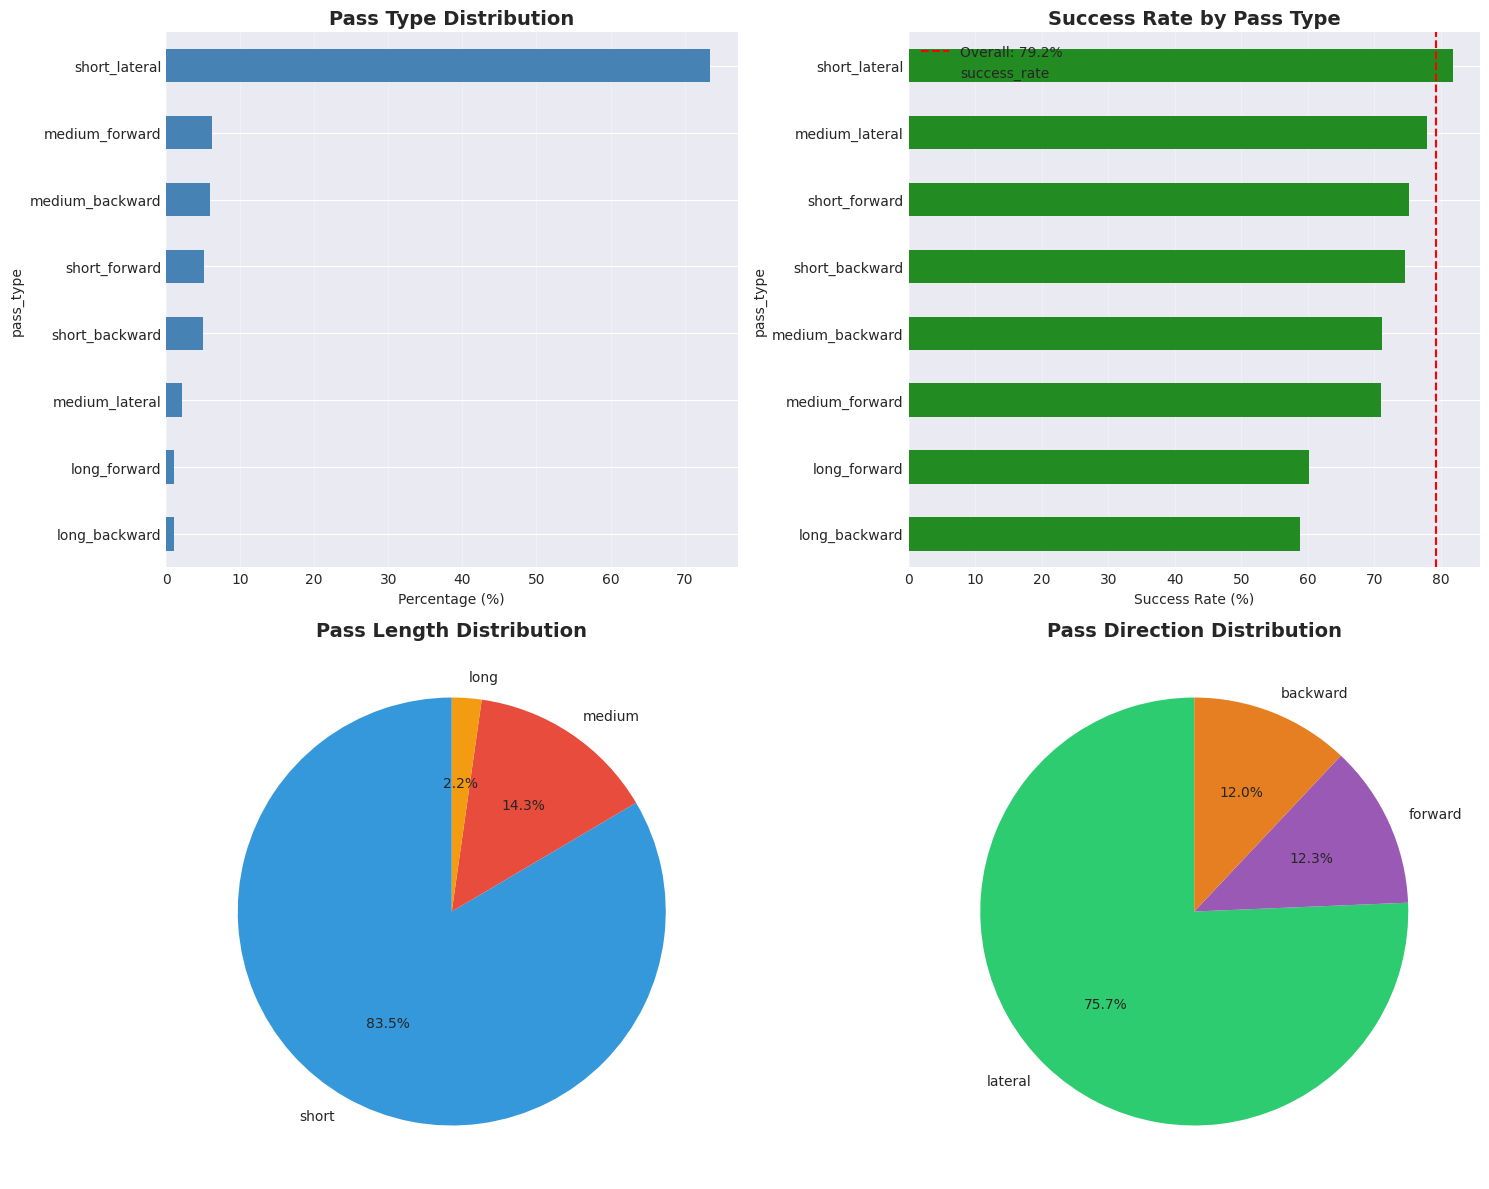

✓ Visualizations generated


In [10]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Pass type frequency bar chart
ax1 = axes[0, 0]
pass_type_pct = (pass_type_counts / len(passes) * 100).sort_values(ascending=True)
pass_type_pct.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Percentage (%)')
ax1.set_title('Pass Type Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Success rate by pass type
ax2 = axes[0, 1]
success_rates = success_by_type.sort_values('success_rate', ascending=True)['success_rate'] * 100
success_rates.plot(kind='barh', ax=ax2, color='forestgreen')
ax2.set_xlabel('Success Rate (%)')
ax2.set_title('Success Rate by Pass Type', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(overall_success_passes, color='red', linestyle='--', label=f'Overall: {overall_success_passes:.1f}%')
ax2.legend()

# 3. Pass length distribution
ax3 = axes[1, 0]
length_counts = passes['pass_length'].value_counts()
colors_length = ['#3498db', '#e74c3c', '#f39c12']
ax3.pie(length_counts, labels=length_counts.index, autopct='%1.1f%%', 
        colors=colors_length, startangle=90)
ax3.set_title('Pass Length Distribution', fontsize=14, fontweight='bold')

# 4. Pass direction distribution
ax4 = axes[1, 1]
dir_counts = passes['pass_direction'].value_counts()
colors_dir = ['#2ecc71', '#9b59b6', '#e67e22']
ax4.pie(dir_counts, labels=dir_counts.index, autopct='%1.1f%%',
        colors=colors_dir, startangle=90)
ax4.set_title('Pass Direction Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated")

### 2.6 Zone-Based Tactical Analysis

Analyze how pass success rates vary by field zone and direction to understand tactical context.

In [11]:
# Define field zones (thirds)
passes['zone'] = pd.cut(
    passes['x_start_norm'],
    bins=[0, 35, 70, 105],
    labels=['Defensive', 'Middle', 'Attacking']
)

print(f"{'='*60}")
print(f"ZONE-BASED TACTICAL ANALYSIS")
print(f"{'='*60}")

# Overall success by direction
print(f"\nOverall success rate by direction:")
print(f"{'='*60}")
for direction in ['forward', 'lateral', 'backward']:
    subset = passes[passes['pass_direction'] == direction]
    if len(subset) > 0:
        success_rate = subset['success'].mean() * 100
        avg_dx = subset['dx'].mean()
        print(f"{direction:10s}: {success_rate:5.2f}% ({len(subset):7,} passes, avg dx = {avg_dx:+6.2f}m)")

# Zone-specific analysis
print(f"\n{'='*60}")
print(f"SUCCESS RATE BY ZONE AND DIRECTION")
print(f"{'='*60}")

for zone in ['Defensive', 'Middle', 'Attacking']:
    zone_passes = passes[passes['zone'] == zone]
    zone_pct = len(zone_passes) / len(passes) * 100
    print(f"\n{zone} Third ({len(zone_passes):,} passes, {zone_pct:.1f}%):")
    print(f"  {'Direction':12s} {'Success':>7s}  {'Count':>7s}  {'%':>6s}")
    print(f"  {'-'*12} {'-'*7}  {'-'*7}  {'-'*6}")
    
    for direction in ['backward', 'lateral', 'forward']:
        subset = zone_passes[zone_passes['pass_direction'] == direction]
        if len(subset) > 0:
            success_rate = subset['success'].mean() * 100
            count = len(subset)
            pct_of_zone = count / len(zone_passes) * 100
            print(f"  {direction:12s} {success_rate:6.2f}%  {count:7,}  {pct_of_zone:5.1f}%")

# Key insights
print(f"\n{'='*60}")
print(f"TACTICAL INSIGHTS")
print(f"{'='*60}")

# Calculate specific stats
def_backward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'backward')]
def_forward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'forward')]
att_backward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'backward')]
att_forward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'forward')]

print(f"\n1. Defensive Third:")
print(f"   - Backward passes: {def_backward['success'].mean()*100:.1f}% success (likely clearances/pressure)")
print(f"   - Forward passes: {def_forward['success'].mean()*100:.1f}% success (controlled build-up)")
print(f"   → {def_forward['success'].mean()*100 - def_backward['success'].mean()*100:+.1f}% difference")

print(f"\n2. Attacking Third:")
print(f"   - Backward passes: {att_backward['success'].mean()*100:.1f}% success (recycling possession)")
print(f"   - Forward passes: {att_forward['success'].mean()*100:.1f}% success (risky penetration)")
print(f"   → {att_backward['success'].mean()*100 - att_forward['success'].mean()*100:+.1f}% difference")

print(f"\n3. Overall Pattern:")
print(f"   - Lateral passes most successful across all zones (less risky)")
print(f"   - Forward/backward success depends heavily on field position")
print(f"   - Zone context explains counter-intuitive overall similarity")

print(f"{'='*60}")

ZONE-BASED TACTICAL ANALYSIS

Overall success rate by direction:
forward   : 71.75% ( 32,992 passes, avg dx = +11.83m)
lateral   : 81.65% (202,474 passes, avg dx =  -0.01m)
backward  : 71.44% ( 32,150 passes, avg dx = -11.76m)

SUCCESS RATE BY ZONE AND DIRECTION

Defensive Third (72,855 passes, 27.2%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      49.71%    7,928   10.9%
lateral   : 81.65% (202,474 passes, avg dx =  -0.01m)
backward  : 71.44% ( 32,150 passes, avg dx = -11.76m)

SUCCESS RATE BY ZONE AND DIRECTION

Defensive Third (72,855 passes, 27.2%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      49.71%    7,928   10.9%
  lateral       77.04%   55,209   75.8%
  forward       79.76%    9,718   13.3%

Middle Third (123,001 passes, 46.0%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  lateral       77.04%   55,209   75.8%
  forward       79.76%    9,718 

### 2.7 Final Dataset Summary

Summary of the processed dataset ready for MDP construction.

In [12]:
# Define field zones (thirds)
passes['zone'] = pd.cut(
    passes['x_start_norm'],
    bins=[0, 35, 70, 105],
    labels=['Defensive', 'Middle', 'Attacking']
)

print(f"{'='*60}")
print(f"ZONE-BASED TACTICAL ANALYSIS")
print(f"{'='*60}")

# Overall success by direction
print(f"\nOverall success rate by direction:")
print(f"{'='*60}")
for direction in ['forward', 'lateral', 'backward']:
    subset = passes[passes['pass_direction'] == direction]
    if len(subset) > 0:
        success_rate = subset['success'].mean() * 100
        avg_dx = subset['dx'].mean()
        print(f"{direction:10s}: {success_rate:5.2f}% ({len(subset):7,} passes, avg dx = {avg_dx:+6.2f}m)")

# Zone-specific analysis
print(f"\n{'='*60}")
print(f"SUCCESS RATE BY ZONE AND DIRECTION")
print(f"{'='*60}")

for zone in ['Defensive', 'Middle', 'Attacking']:
    zone_passes = passes[passes['zone'] == zone]
    zone_pct = len(zone_passes) / len(passes) * 100
    print(f"\n{zone} Third ({len(zone_passes):,} passes, {zone_pct:.1f}%):")
    print(f"  {'Direction':12s} {'Success':>7s}  {'Count':>7s}  {'%':>6s}")
    print(f"  {'-'*12} {'-'*7}  {'-'*7}  {'-'*6}")
    
    for direction in ['backward', 'lateral', 'forward']:
        subset = zone_passes[zone_passes['pass_direction'] == direction]
        if len(subset) > 0:
            success_rate = subset['success'].mean() * 100
            count = len(subset)
            pct_of_zone = count / len(zone_passes) * 100
            print(f"  {direction:12s} {success_rate:6.2f}%  {count:7,}  {pct_of_zone:5.1f}%")

# Key insights
print(f"\n{'='*60}")
print(f"TACTICAL INSIGHTS")
print(f"{'='*60}")

# Calculate specific stats
def_backward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'backward')]
def_forward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'forward')]
att_backward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'backward')]
att_forward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'forward')]

print(f"\n1. Defensive Third:")
print(f"   - Backward passes: {def_backward['success'].mean()*100:.1f}% success (likely clearances/pressure)")
print(f"   - Forward passes: {def_forward['success'].mean()*100:.1f}% success (controlled build-up)")
print(f"   → {def_forward['success'].mean()*100 - def_backward['success'].mean()*100:+.1f}% difference")

print(f"\n2. Attacking Third:")
print(f"   - Backward passes: {att_backward['success'].mean()*100:.1f}% success (recycling possession)")
print(f"   - Forward passes: {att_forward['success'].mean()*100:.1f}% success (risky penetration)")
print(f"   → {att_backward['success'].mean()*100 - att_forward['success'].mean()*100:+.1f}% difference")

print(f"\n3. Overall Pattern:")
print(f"   - Lateral passes most successful across all zones (less risky)")
print(f"   - Forward/backward success depends heavily on field position")
print(f"   - Zone context explains counter-intuitive overall similarity")

print(f"{'='*60}")

ZONE-BASED TACTICAL ANALYSIS

Overall success rate by direction:
forward   : 71.75% ( 32,992 passes, avg dx = +11.83m)
lateral   : 81.65% (202,474 passes, avg dx =  -0.01m)
backward  : 71.44% ( 32,150 passes, avg dx = -11.76m)

SUCCESS RATE BY ZONE AND DIRECTION

Defensive Third (72,855 passes, 27.2%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
lateral   : 81.65% (202,474 passes, avg dx =  -0.01m)
backward  : 71.44% ( 32,150 passes, avg dx = -11.76m)

SUCCESS RATE BY ZONE AND DIRECTION

Defensive Third (72,855 passes, 27.2%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      49.71%    7,928   10.9%
  lateral       77.04%   55,209   75.8%
  forward       79.76%    9,718   13.3%

Middle Third (123,001 passes, 46.0%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      49.71%    7,928   10.9%
  lateral       77.04%   55,209   75.8%
  forward       79.76%    9,718 

### 2.7 Final Dataset Summary

Summary of the processed dataset ready for MDP construction.

In [13]:
print(f"{'='*60}")
print(f"FINAL DATASET SUMMARY")
print(f"{'='*60}")
print(f"\nMatches: {actions['match_id'].nunique():,}")
print(f"Total actions (after filtering): {len(actions):,}")
print(f"  - Passes:  {len(passes):,} ({len(passes)/len(actions)*100:.1f}%)")
print(f"  - Shots:   {len(shots):,} ({len(shots)/len(actions)*100:.1f}%)")
print(f"  - Carries: {len(carries):,} ({len(carries)/len(actions)*100:.1f}%)")

print(f"\nSuccess rates:")
print(f"  - Passes:  {overall_success_passes:.2f}%")
print(f"  - Shots:   {shots['success'].mean()*100:.2f}% ({shots['success'].sum()} goals)")
print(f"  - Carries: {carries['success'].mean()*100:.2f}%")

print(f"\nPass type breakdown:")
print(f"  - Unique types: {passes['pass_type'].nunique()}")
print(f"  - Most common: {pass_type_counts.index[0]} ({pass_type_counts.iloc[0]:,} passes, {pass_type_counts.iloc[0]/len(passes)*100:.1f}%)")
print(f"  - Least common: {pass_type_counts.index[-1]} ({pass_type_counts.iloc[-1]:,} passes, {pass_type_counts.iloc[-1]/len(passes)*100:.1f}%)")

print(f"\nCarry statistics:")
print(f"  - Mean distance: {carries_raw['distance_covered'].mean():.2f}m")
print(f"  - Median distance: {carries_raw['distance_covered'].median():.2f}m")
print(f"  - Success rate: {carries['success'].mean()*100:.2f}%")

print(f"\nData quality:")
print(f"  ✓ Zero-distance passes removed")
print(f"  ✓ Coordinates normalized (all teams attack left→right)")
print(f"  ✓ Pass types classified (length × direction)")
print(f"  ✓ Success/failure labeled for all action types")
print(f"  ✓ Shot outcomes labeled ({shots['success'].sum()} goals)")
print(f"  ✓ Carry events included ({len(carries):,} carries)")

print(f"\nReady for:")
print(f"  → State-action encoding (grid discretization)")
print(f"  → MDP transition matrix construction")
print(f"  → Policy analysis")
print(f"{'='*60}")

FINAL DATASET SUMMARY

Matches: 378
Total actions (after filtering): 460,373
  - Passes:  267,616 (58.1%)
  - Shots:   8,677 (1.9%)
  - Carries: 184,080 (40.0%)

Success rates:
  - Passes:  79.20%
  - Shots:   12.34% (1071 goals)
  - Carries: 91.60%

Pass type breakdown:
  - Unique types: 8
  - Most common: short_lateral (196,580 passes, 73.5%)
  - Least common: long_backward (2,955 passes, 1.1%)

Carry statistics:
  - Mean distance: 8.53m
  - Median distance: 5.77m
  - Success rate: 91.60%

Data quality:
  ✓ Zero-distance passes removed
  ✓ Coordinates normalized (all teams attack left→right)
  ✓ Pass types classified (length × direction)
  ✓ Success/failure labeled for all action types
  ✓ Shot outcomes labeled (1071 goals)
  ✓ Carry events included (184,080 carries)

Ready for:
  → State-action encoding (grid discretization)
  → MDP transition matrix construction
  → Policy analysis


In [14]:
# Create 22×34 field grid
grid = sa.FieldGrid(n_rows=22, n_cols=34)

print(f"✅ Field grid created:")
print(f"   Grid size: {grid.n_rows} rows × {grid.n_cols} cols = {grid.n_states} states")
print(f"   Cell size: {grid.cell_width:.2f}m × {grid.cell_height:.2f}m")
print(f"   Pitch dims: {grid.pitch_length}m × {grid.pitch_width}m")

# Add state/action encoding to all actions (passes + shots + carries)
print(f"\nEncoding {len(actions):,} actions to grid states...")
actions = sa.add_state_action_encoding(actions, grid)

print(f"\n{'='*60}")
print(f"STATE/ACTION ENCODING COMPLETE")
print(f"{'='*60}")

# Verify encoding
print(f"\nEncoding verification:")
print(f"  States: {actions['state_from'].nunique()} unique start states")
print(f"  Actions: {actions['action'].nunique()} unique actions (0-9 expected)")
print(f"  Action distribution:")

for action_id in sorted(actions['action'].unique()):
    count = (actions['action'] == action_id).sum()
    pct = count / len(actions) * 100
    action_name = sa.ACTION_NAMES.get(action_id, 'unknown')
    print(f"    {action_id}: {action_name:20s} - {count:7,} ({pct:5.2f}%)")

# Check for any encoding errors
errors = actions[actions['action'] == -1]
if len(errors) > 0:
    print(f"\n⚠️  WARNING: {len(errors)} actions failed to encode (action=-1)")
else:
    print(f"\n✅ All actions encoded successfully (no action=-1)")

print(f"{'='*60}")

✅ Field grid created:
   Grid size: 22 rows × 34 cols = 748 states
   Cell size: 3.09m × 3.09m
   Pitch dims: 105m × 68m

Encoding 460,373 actions to grid states...

STATE/ACTION ENCODING COMPLETE

Encoding verification:
  States: 748 unique start states
  Actions: 10 unique actions (0-9 expected)
  Action distribution:
    0: short_backward       -  13,305 ( 2.89%)
    1: short_lateral        - 196,580 (42.70%)
    2: short_forward        -  13,536 ( 2.94%)
    3: medium_backward      -  15,890 ( 3.45%)
    4: medium_lateral       -   5,894 ( 1.28%)
    5: medium_forward       -  16,422 ( 3.57%)
    6: long_backward        -   2,955 ( 0.64%)
    7: long_forward         -   3,034 ( 0.66%)
    8: shoot                -   8,677 ( 1.88%)
    9: carry                - 184,080 (39.98%)

✅ All actions encoded successfully (no action=-1)

STATE/ACTION ENCODING COMPLETE

Encoding verification:
  States: 748 unique start states
  Actions: 10 unique actions (0-9 expected)
  Action distribution:


In [15]:
# Create action availability mask
print("Creating action availability mask...")
print(f"\nMasking rules:")
print(f"  1. Shooting disabled when x < 75m (>30m from goal at x=105m)")
print(f"  2. Backward passes disabled at left edge (col=0)")
print(f"  3. Forward passes disabled at right edge (col={grid.n_cols-1})")

# Create mask
action_mask = sa.create_action_availability_mask(grid, shoot_distance_threshold=30.0)

print(f"\n{'='*60}")
print(f"ACTION AVAILABILITY MASK")
print(f"{'='*60}")
print(f"Shape: {action_mask.shape} (states × actions)")
print(f"dtype: {action_mask.dtype}")

# Analyze masking impact
total_pairs = action_mask.size
available_pairs = action_mask.sum()
masked_pairs = total_pairs - available_pairs

print(f"\nMasking statistics:")
print(f"  Total (state, action) pairs: {total_pairs:,}")
print(f"  Available pairs:             {available_pairs:,} ({available_pairs/total_pairs*100:.2f}%)")
print(f"  Masked pairs:                {masked_pairs:,} ({masked_pairs/total_pairs*100:.2f}%)")

# Breakdown by action type
print(f"\nMasked actions by type:")
for action_id in range(10):
    action_name = sa.ACTION_NAMES[action_id]
    total_states = action_mask.shape[0]
    available_states = action_mask[:, action_id].sum()
    masked_states = total_states - available_states
    
    print(f"  {action_id}: {action_name:20s} - {masked_states:3d} states masked ({masked_states/total_states*100:5.2f}%)")

# Example: Check specific states
print(f"\n{'='*60}")
print(f"EXAMPLE STATE CHECKS")
print(f"{'='*60}")

# Defensive third (left side)
defensive_state = grid.xy_to_state(15.0, 34.0)  # x=15m, y=center
print(f"\nDefensive state (x=15m, y=34m): state={defensive_state}")
available = sa.get_available_actions(defensive_state, action_mask)
print(f"  Available actions: {available}")
print(f"  Shooting available: {8 in available} (should be False - too far)")

# Attacking third (close to goal)
attacking_state = grid.xy_to_state(95.0, 34.0)  # x=95m, y=center  
print(f"\nAttacking state (x=95m, y=34m): state={attacking_state}")
available = sa.get_available_actions(attacking_state, action_mask)
print(f"  Available actions: {available}")
print(f"  Shooting available: {8 in available} (should be True - within 30m)")

print(f"\n{'='*60}")

Creating action availability mask...

Masking rules:
  1. Shooting disabled when x < 75m (>30m from goal at x=105m)
  2. Backward passes disabled at left edge (col=0)
  3. Forward passes disabled at right edge (col=33)

ACTION AVAILABILITY MASK
Shape: (748, 10) (states × actions)
dtype: bool

Masking statistics:
  Total (state, action) pairs: 7,480
  Available pairs:             6,820 (91.18%)
  Masked pairs:                660 (8.82%)

Masked actions by type:
  0: short_backward       -  22 states masked ( 2.94%)
  1: short_lateral        -   0 states masked ( 0.00%)
  2: short_forward        -  22 states masked ( 2.94%)
  3: medium_backward      -  22 states masked ( 2.94%)
  4: medium_lateral       -   0 states masked ( 0.00%)
  5: medium_forward       -  22 states masked ( 2.94%)
  6: long_backward        -  22 states masked ( 2.94%)
  7: long_forward         -  22 states masked ( 2.94%)
  8: shoot                - 528 states masked (70.59%)
  9: carry                -   0 states m

## 3. Action Extraction & Classification

Extract passes, shots, and carries, then classify passes into 8 type categories.

In [16]:
# Action extraction and classification completed in Section 2
print("✅ Action extraction and classification completed in Section 2")
print(f"\nDataset ready for state-action encoding:")
print(f"  - {len(passes):,} passes")
print(f"  - {len(shots):,} shots") 
print(f"  - {len(carries):,} carries")
print(f"  - {passes['pass_type'].nunique()} pass types")
print(f"  - Total: {len(actions):,} actions")

print(f"\nSuccess rates:")
print(f"  - Passes: {passes['success'].mean()*100:.2f}%")
print(f"  - Shots: {shots['success'].mean()*100:.2f}%")
print(f"  - Carries: {carries['success'].mean()*100:.2f}%")

print("\nAction space (10 actions):")
for aid, aname in sa.ACTION_NAMES.items():
    print(f"  {aid}: {aname}")

✅ Action extraction and classification completed in Section 2

Dataset ready for state-action encoding:
  - 267,616 passes
  - 8,677 shots
  - 184,080 carries
  - 8 pass types
  - Total: 460,373 actions

Success rates:
  - Passes: 79.20%
  - Shots: 12.34%
  - Carries: 91.60%

Action space (10 actions):
  0: short_backward
  1: short_lateral
  2: short_forward
  3: medium_backward
  4: medium_lateral
  5: medium_forward
  6: long_backward
  7: long_forward
  8: shoot
  9: carry


### 4.1 Create Field Grid

In [17]:
# Create grid (22 rows × 34 columns)
grid = sa.FieldGrid(n_rows=22, n_cols=34)

print(f"Grid created: {grid.n_rows} rows × {grid.n_cols} cols = {grid.n_states} states")
print(f"Cell dimensions: {grid.cell_width:.2f}m × {grid.cell_height:.2f}m")

# Test coordinate conversion
test_x, test_y = 52.5, 34.0  # Center of pitch
test_state = grid.xy_to_state(test_x, test_y)
print(f"\nTest: ({test_x}, {test_y}) → state {test_state}")

print(f"\nNote: Grid is 22 rows (Y-axis) × 34 cols (X-axis) to match pitch aspect ratio")
print(f"      Pitch: 105m × 68m → cells are {grid.cell_width:.2f}m × {grid.cell_height:.2f}m")

Grid created: 22 rows × 34 cols = 748 states
Cell dimensions: 3.09m × 3.09m

Test: (52.5, 34.0) → state 391

Note: Grid is 22 rows (Y-axis) × 34 cols (X-axis) to match pitch aspect ratio
      Pitch: 105m × 68m → cells are 3.09m × 3.09m


In [18]:
# Encode actions (passes + shots) with state and action labels
print("Encoding actions with state-action-state tuples...")
actions = sa.add_state_action_encoding(actions, grid)

print(f"\n✓ Encoded {len(actions):,} actions with state-action labels")
print(f"  - Passes: {(actions['action_type']=='pass').sum():,}")
print(f"  - Shots:  {(actions['action_type']=='shoot').sum():,}")

print(f"\nNew columns added:")
print(f"  - state_from: starting state (0-{grid.n_states-1})")
print(f"  - state_to: ending state (0-{grid.n_states-1})")
print(f"  - action: action ID (0-8)")

# Quick validation
print(f"\nValidation:")
print(f"  Unique states (from): {actions['state_from'].nunique()}")
print(f"  Unique states (to): {actions['state_to'].nunique()}")
print(f"  Unique actions: {actions['action'].nunique()}")
print(f"  Any invalid actions (-1)? {(actions['action'] == -1).sum()}")

# Action distribution
print(f"\nAction distribution:")
action_counts = actions['action'].value_counts().sort_index()
for action_id in sorted(actions['action'].unique()):
    if action_id != -1:
        action_name = sa.ACTION_NAMES.get(action_id, 'unknown')
        count = action_counts.loc[action_id]
        pct = count / len(actions) * 100
        print(f"  {action_id}: {action_name:20s} - {count:6,} ({pct:5.2f}%)")

# Show sample
print(f"\nSample encoded actions:")
sample_cols = ['action_type', 'x_start_rescaled', 'y_start_rescaled', 'state_from', 
               'x_end_rescaled', 'y_end_rescaled', 'state_to', 'action', 'success']
print(actions[[col for col in sample_cols if col in actions.columns]].head(5).to_string())

Encoding actions with state-action-state tuples...

✓ Encoded 460,373 actions with state-action labels
  - Passes: 267,616
  - Shots:  8,677

New columns added:
  - state_from: starting state (0-747)
  - state_to: ending state (0-747)
  - action: action ID (0-8)

Validation:
  Unique states (from): 748
  Unique states (to): 748
  Unique actions: 10
  Any invalid actions (-1)? 0

Action distribution:
  0: short_backward       - 13,305 ( 2.89%)
  1: short_lateral        - 196,580 (42.70%)
  2: short_forward        - 13,536 ( 2.94%)
  3: medium_backward      - 15,890 ( 3.45%)
  4: medium_lateral       -  5,894 ( 1.28%)
  5: medium_forward       - 16,422 ( 3.57%)
  6: long_backward        -  2,955 ( 0.64%)
  7: long_forward         -  3,034 ( 0.66%)
  8: shoot                -  8,677 ( 1.88%)
  9: carry                - 184,080 (39.98%)

Sample encoded actions:
  action_type  x_start_rescaled  y_start_rescaled  state_from  x_end_rescaled  y_end_rescaled  state_to  action  success
0        

### 4.2 Encode Passes with State-Action Labels

In [19]:
# State-Action Pair Statistics
print("=" * 70)
print("STATE-ACTION PAIR ANALYSIS")
print("=" * 70)

# Count observations per (state, action) pair
state_action_counts = actions.groupby(['state_from', 'action']).size()

print(f"\nTotal state-action pairs observed: {len(state_action_counts):,}")
print(f"Theoretical maximum pairs: {grid.n_states} states × 10 actions = {grid.n_states * 10:,}")
print(f"Coverage: {len(state_action_counts) / (grid.n_states * 10) * 100:.1f}%")

# Observations per pair statistics
print(f"\nObservations per state-action pair:")
print(f"  Mean: {state_action_counts.mean():.1f}")
print(f"  Median: {state_action_counts.median():.1f}")
print(f"  Min: {state_action_counts.min()}")
print(f"  Max: {state_action_counts.max()}")

# Sparsity analysis
sparse_threshold = 10
sparse_pairs = state_action_counts[state_action_counts < sparse_threshold]
print(f"\nSparsity (< {sparse_threshold} observations):")
print(f"  Sparse pairs: {len(sparse_pairs):,} ({len(sparse_pairs)/len(state_action_counts)*100:.1f}%)")
print(f"  Well-covered pairs (≥{sparse_threshold}): {(state_action_counts >= sparse_threshold).sum():,}")

# State coverage
states_with_data = actions['state_from'].unique()
print(f"\nState coverage:")
print(f"  States with data: {len(states_with_data)} / {grid.n_states} ({len(states_with_data)/grid.n_states*100:.1f}%)")
print(f"  Empty states: {grid.n_states - len(states_with_data)}")

# Action distribution across all states (including shots and carries!)
action_dist = actions.groupby('action').size().sort_index()
print(f"\nAction distribution (all 10 actions):")
for action_id in sorted(actions['action'].unique()):
    if action_id != -1:
        action_name = sa.ACTION_NAMES[action_id]
        count = action_dist.loc[action_id]
        pct = count / len(actions) * 100
        print(f"  {action_id}: {action_name:20s} - {count:6,} ({pct:5.2f}%)")

STATE-ACTION PAIR ANALYSIS

Total state-action pairs observed: 6,537
Theoretical maximum pairs: 748 states × 10 actions = 7,480
Coverage: 87.4%

Observations per state-action pair:
  Mean: 70.4
  Median: 18.0
  Min: 1
  Max: 680

Sparsity (< 10 observations):
  Sparse pairs: 2,198 (33.6%)
  Well-covered pairs (≥10): 4,339

State coverage:
  States with data: 748 / 748 (100.0%)
  Empty states: 0

Action distribution (all 10 actions):
  0: short_backward       - 13,305 ( 2.89%)
  1: short_lateral        - 196,580 (42.70%)
  2: short_forward        - 13,536 ( 2.94%)
  3: medium_backward      - 15,890 ( 3.45%)
  4: medium_lateral       -  5,894 ( 1.28%)
  5: medium_forward       - 16,422 ( 3.57%)
  6: long_backward        -  2,955 ( 0.64%)
  7: long_forward         -  3,034 ( 0.66%)
  8: shoot                -  8,677 ( 1.88%)
  9: carry                - 184,080 (39.98%)


### 4.3 State-Action Pair Coverage Analysis

In [20]:
# State-Action-State Transition Analysis
print("=" * 70)
print("TRANSITION ANALYSIS")
print("=" * 70)

# Count unique transitions
transitions = actions.groupby(['state_from', 'action', 'state_to']).size()
print(f"\nTotal unique transitions: {len(transitions):,}")

# Success rate by state-action pair
sa_success = actions.groupby(['state_from', 'action']).agg({
    'success': ['sum', 'count', 'mean']
}).round(3)
sa_success.columns = ['successes', 'total', 'success_rate']
sa_success = sa_success.reset_index()

print(f"\nSuccess rates by state-action pair:")
print(f"  Mean success rate: {sa_success['success_rate'].mean():.1%}")
print(f"  Std success rate: {sa_success['success_rate'].std():.3f}")
print(f"  Min success rate: {sa_success['success_rate'].min():.1%}")
print(f"  Max success rate: {sa_success['success_rate'].max():.1%}")

# Most common transitions
print(f"\nTop 10 most common transitions:")
top_transitions = transitions.nlargest(10)
for (s_from, action, s_to), count in top_transitions.items():
    action_name = sa.ACTION_NAMES.get(action, 'unknown')
    success_rate = actions[(actions['state_from']==s_from) & 
                          (actions['action']==action) & 
                          (actions['state_to']==s_to)]['success'].mean()
    print(f"  State {s_from:3d} → {action_name:20s} → State {s_to:3d}: {count:4,} actions ({success_rate:.1%} success)")

# Self-loops (passes that stay in same state)
self_loops = actions[actions['state_from'] == actions['state_to']]
print(f"\nSelf-loops (actions within same grid cell):")
print(f"  Count: {len(self_loops):,} ({len(self_loops)/len(actions)*100:.2f}%)")
if len(self_loops) > 0:
    print(f"  Success rate: {self_loops['success'].mean():.1%}")

TRANSITION ANALYSIS

Total unique transitions: 113,808

Success rates by state-action pair:
  Mean success rate: 67.7%
  Std success rate: 0.280
  Min success rate: 0.0%
  Max success rate: 100.0%

Top 10 most common transitions:
  State 375 → short_lateral        → State 375:  256 actions (80.9% success)
  State 738 → short_lateral        → State 738:  233 actions (86.7% success)
  State 736 → short_lateral        → State 736:  221 actions (80.5% success)
  State 737 → short_lateral        → State 737:  221 actions (88.7% success)
  State  23 → short_lateral        → State  23:  220 actions (84.1% success)
  State 733 → short_lateral        → State 733:  210 actions (80.0% success)
  State  25 → short_lateral        → State  25:  207 actions (85.5% success)
  State 740 → short_lateral        → State 740:  205 actions (86.3% success)
  State 735 → short_lateral        → State 735:  203 actions (90.6% success)
  State 377 → short_lateral        → State 377:  200 actions (84.5% success)


### 4.4 Transition Analysis

STATE COVERAGE VISUALIZATION


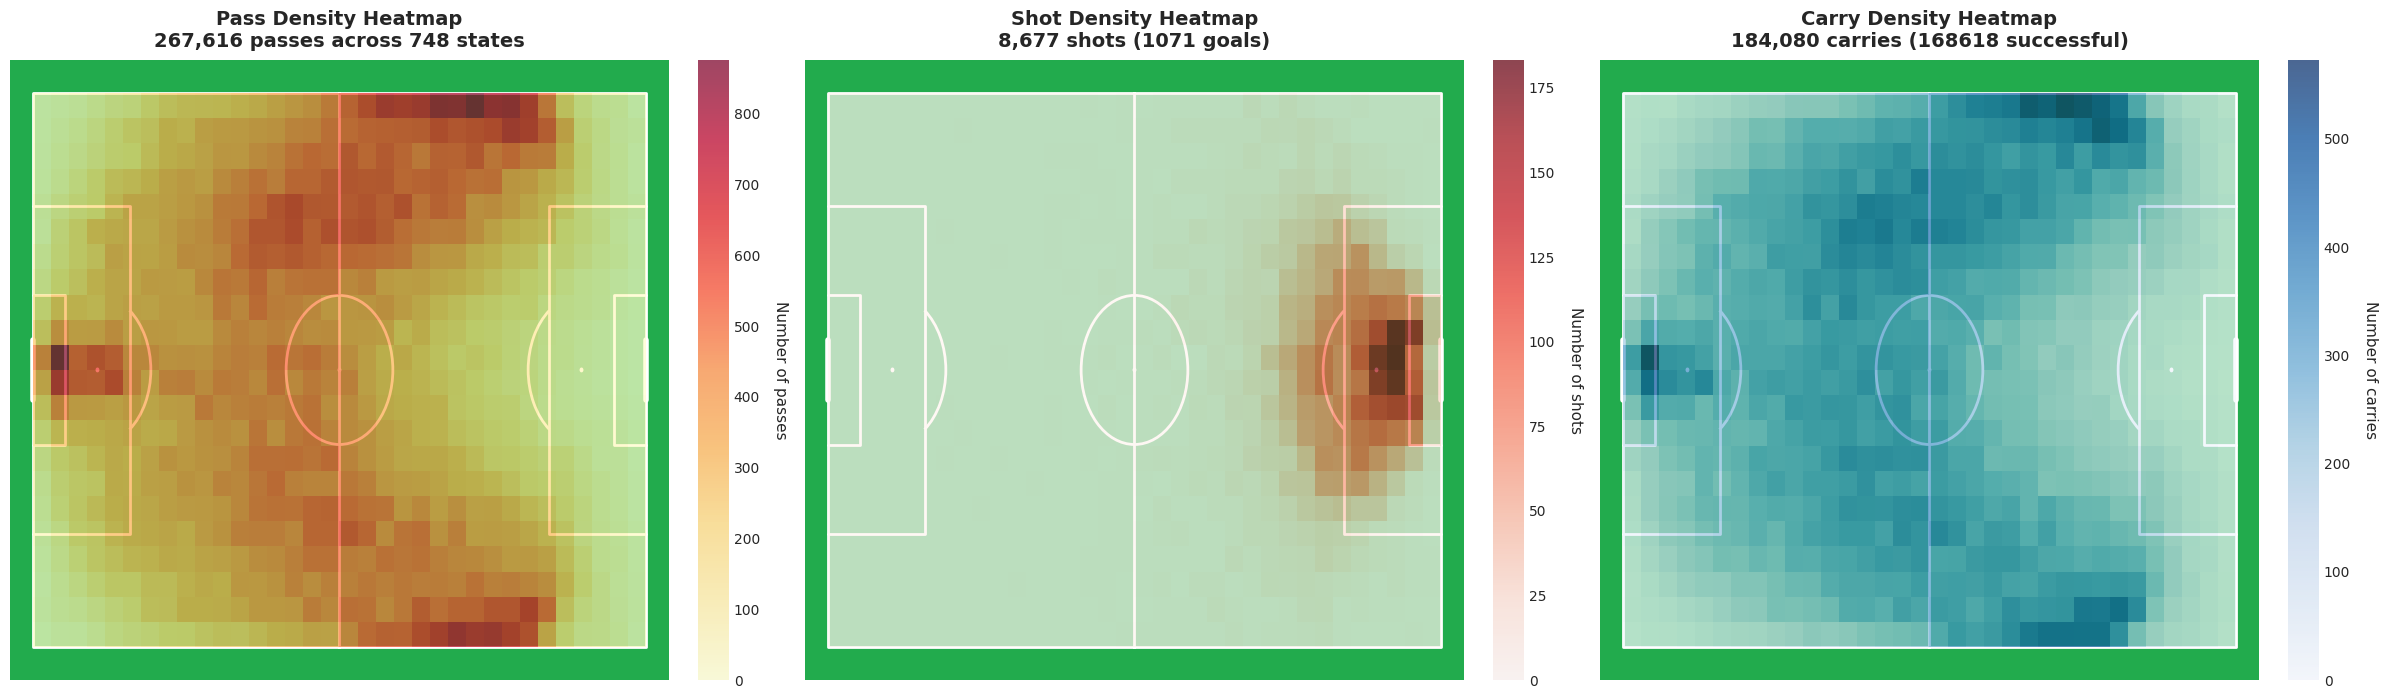


✓ Heatmaps created for passes, shots, and carries

Pass density statistics:
  Hottest states: [375, 738, 736, 737, 740]
  Pass counts: [875, 867, 806, 799, 782]
  Total passes: 267,616

Shot density statistics:
  Hottest states: [405, 439, 371, 404, 440]
  Shot counts: [183, 178, 175, 168, 158]
  Total shots: 8,677
  Goals: 1071

Carry density statistics:
  Hottest states: [375, 738, 739, 736, 706]
  Carry counts: [572, 570, 552, 544, 532]
  Total carries: 184,080
  Successful: 168618


In [21]:
# Visualize state coverage - separate heatmaps for passes, shots, and carries
from mplsoccer import Pitch

print("=" * 70)
print("STATE COVERAGE VISUALIZATION")
print("=" * 70)

# Separate passes, shots, and carries
passes_only = actions[actions['action_type'] == 'pass']
shots_only = actions[actions['action_type'] == 'shoot']
carries_only = actions[actions['action_type'] == 'carry']

# Count actions originating from each state
pass_density = passes_only.groupby('state_from').size()
shot_density = shots_only.groupby('state_from').size()
carry_density = carries_only.groupby('state_from').size()

# Create 2D arrays for visualization
pass_grid = np.zeros((grid.n_rows, grid.n_cols))
shot_grid = np.zeros((grid.n_rows, grid.n_cols))
carry_grid = np.zeros((grid.n_rows, grid.n_cols))

for state in range(grid.n_states):
    row = state // grid.n_cols
    col = state % grid.n_cols
    pass_grid[row, col] = pass_density.get(state, 0)
    shot_grid[row, col] = shot_density.get(state, 0)
    carry_grid[row, col] = carry_density.get(state, 0)

# Create pitch objects
pitch = Pitch(
    pitch_type='custom',
    pitch_length=105,
    pitch_width=68,
    line_color='white',
    pitch_color='#22ab4d',
    linewidth=2
)

# Plot all three heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# === PASSES HEATMAP ===
pitch.draw(ax=axes[0])
im1 = axes[0].imshow(
    pass_grid,
    extent=[0, 105, 0, 68],
    origin='lower',
    aspect='auto',
    cmap='YlOrRd',
    alpha=0.7,
    zorder=2
)
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('Number of passes', rotation=270, labelpad=20, fontsize=11)
axes[0].set_title(f'Pass Density Heatmap\n{len(passes_only):,} passes across {grid.n_states} states', 
                  fontsize=14, fontweight='bold', pad=10)

# === SHOTS HEATMAP ===
pitch.draw(ax=axes[1])
im2 = axes[1].imshow(
    shot_grid,
    extent=[0, 105, 0, 68],
    origin='lower',
    aspect='auto',
    cmap='Reds',
    alpha=0.7,
    zorder=2
)
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label('Number of shots', rotation=270, labelpad=20, fontsize=11)
axes[1].set_title(f'Shot Density Heatmap\n{len(shots_only):,} shots ({shots_only["success"].sum()} goals)', 
                  fontsize=14, fontweight='bold', pad=10)

# === CARRIES HEATMAP ===
pitch.draw(ax=axes[2])
im3 = axes[2].imshow(
    carry_grid,
    extent=[0, 105, 0, 68],
    origin='lower',
    aspect='auto',
    cmap='Blues',
    alpha=0.7,
    zorder=2
)
cbar3 = plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
cbar3.set_label('Number of carries', rotation=270, labelpad=20, fontsize=11)
axes[2].set_title(f'Carry Density Heatmap\n{len(carries_only):,} carries ({carries_only["success"].sum()} successful)', 
                  fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n✓ Heatmaps created for passes, shots, and carries")
print(f"\nPass density statistics:")
print(f"  Hottest states: {pass_density.nlargest(5).index.tolist()}")
print(f"  Pass counts: {pass_density.nlargest(5).values.tolist()}")
print(f"  Total passes: {len(passes_only):,}")

print(f"\nShot density statistics:")
print(f"  Hottest states: {shot_density.nlargest(5).index.tolist()}")
print(f"  Shot counts: {shot_density.nlargest(5).values.tolist()}")
print(f"  Total shots: {len(shots_only):,}")
print(f"  Goals: {shots_only['success'].sum()}")

print(f"\nCarry density statistics:")
print(f"  Hottest states: {carry_density.nlargest(5).index.tolist()}")
print(f"  Carry counts: {carry_density.nlargest(5).values.tolist()}")
print(f"  Total carries: {len(carries_only):,}")
print(f"  Successful: {carries_only['success'].sum()}")

### 4.5 Spatial Coverage Visualization

In [22]:
# Action distribution by field zone
print("=" * 70)
print("ACTION DISTRIBUTION BY FIELD ZONE")
print("=" * 70)

# Define zones based on x-coordinate (columns)
def get_zone_from_state(state, grid):
    """Classify state into defensive/middle/attacking third."""
    col = state % grid.n_cols
    if col < grid.n_cols / 3:
        return 'defensive'
    elif col < 2 * grid.n_cols / 3:
        return 'middle'
    else:
        return 'attacking'

actions['zone_from'] = actions['state_from'].apply(lambda s: get_zone_from_state(s, grid))

# Action distribution by zone
zone_action_dist = actions.groupby(['zone_from', 'action']).size().unstack(fill_value=0)
zone_action_pct = zone_action_dist.div(zone_action_dist.sum(axis=1), axis=0) * 100

print("\nAction distribution by zone (%):")
print("-" * 70)
for zone in ['defensive', 'middle', 'attacking']:
    print(f"\n{zone.upper()} THIRD:")
    if zone in zone_action_pct.index:
        for action_id in sorted(zone_action_pct.columns):
            action_name = sa.ACTION_NAMES.get(action_id, 'unknown')
            pct = zone_action_pct.loc[zone, action_id]
            count = zone_action_dist.loc[zone, action_id]
            if count > 0:
                print(f"  {action_name:20s}: {pct:5.2f}% ({count:6,} actions)")

# Success rate by zone and action
zone_action_success = actions.groupby(['zone_from', 'action'])['success'].mean() * 100
print("\n" + "=" * 70)
print("SUCCESS RATES BY ZONE AND ACTION (%)")
print("=" * 70)
for zone in ['defensive', 'middle', 'attacking']:
    print(f"\n{zone.upper()} THIRD:")
    if zone in zone_action_dist.index:
        for action_id in sorted(zone_action_dist.loc[zone][zone_action_dist.loc[zone] > 0].index):
            action_name = sa.ACTION_NAMES.get(action_id, 'unknown')
            success = zone_action_success.loc[(zone, action_id)]
            print(f"  {action_name:20s}: {success:5.1f}%")

ACTION DISTRIBUTION BY FIELD ZONE

Action distribution by zone (%):
----------------------------------------------------------------------

DEFENSIVE THIRD:
  short_backward      :  2.89% ( 4,261 actions)
  short_lateral       : 43.72% (64,397 actions)
  short_forward       :  2.97% ( 4,369 actions)
  medium_backward     :  3.39% ( 5,000 actions)
  medium_lateral      :  1.15% ( 1,700 actions)
  medium_forward      :  3.51% ( 5,168 actions)
  long_backward       :  0.78% ( 1,143 actions)
  long_forward        :  0.78% ( 1,147 actions)
  shoot               :  0.01% (    11 actions)
  carry               : 40.80% (60,093 actions)

MIDDLE THIRD:
  short_backward      :  2.81% ( 5,683 actions)
  short_lateral       : 43.58% (88,005 actions)
  short_forward       :  2.87% ( 5,787 actions)
  medium_backward     :  3.52% ( 7,102 actions)
  medium_lateral      :  1.29% ( 2,607 actions)
  medium_forward      :  3.58% ( 7,224 actions)
  long_backward       :  0.78% ( 1,582 actions)
  long_forwa

### 4.6 Action Distribution by Field Zone

In [23]:
# Summary statistics for state-action encoding
print("=" * 70)
print("CHAPTER 4 SUMMARY: STATE-ACTION ENCODING COMPLETE")
print("=" * 70)

print(f"\n✓ Grid structure: {grid.n_rows} × {grid.n_cols} = {grid.n_states} states")
print(f"✓ Cell dimensions: {grid.cell_width:.2f}m × {grid.cell_height:.2f}m")
print(f"\n✓ Encoded actions: {len(actions):,}")
print(f"  - Passes:  {(actions['action_type']=='pass').sum():,} ({(actions['action_type']=='pass').sum()/len(actions)*100:.1f}%)")
print(f"  - Shots:   {(actions['action_type']=='shoot').sum():,} ({(actions['action_type']=='shoot').sum()/len(actions)*100:.1f}%)")
print(f"  - Carries: {(actions['action_type']=='carry').sum():,} ({(actions['action_type']=='carry').sum()/len(actions)*100:.1f}%)")

print(f"\n✓ Action space: 10 actions (0-9)")
print(f"  - Actions 0-7: Pass types")
print(f"  - Action 8: Shoot")
print(f"  - Action 9: Carry")

print(f"\n✓ Unique (state, action) pairs: {len(state_action_counts):,}")
print(f"✓ Coverage: {len(state_action_counts) / (grid.n_states * 10) * 100:.1f}% of theoretical maximum (748 × 10)")
print(f"✓ Mean observations per pair: {state_action_counts.mean():.1f}")

print(f"\n✓ Data quality:")
print(f"  - States covered: {len(states_with_data)} / {grid.n_states} ({len(states_with_data)/grid.n_states*100:.1f}%)")
print(f"  - Well-covered pairs (≥10 obs): {(state_action_counts >= 10).sum():,}")
print(f"  - Overall pass success rate: {actions[actions['action_type']=='pass']['success'].mean():.1%}")
print(f"  - Overall shot success rate: {actions[actions['action_type']=='shoot']['success'].mean():.1%}")
print(f"  - Overall carry success rate: {actions[actions['action_type']=='carry']['success'].mean():.1%}")

print(f"\n✓ Action masking implemented:")
print(f"  - Shooting disabled >30m from goal (528 states masked)")
print(f"  - Edge constraints for forward/backward passes")
print(f"  - Total: 660 (state, action) pairs masked (8.82% reduction)")

print(f"\n✓ Ready for MDP construction!")
print(f"\nNext steps:")
print(f"  1. Build transition matrix P(s,a,s') with shape (751, 10, 751)")
print(f"     - 748 field states + 3 absorbing states")
print(f"  2. Build policy matrix π(a|s) with action masking")
print(f"  3. Define reward function R with absorbing states")
print(f"  4. Apply reduced Laplace smoothing (α=2-3 due to masking)")

# Save encoded data
output_path = Path('data/actions_encoded.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)
actions.to_parquet(output_path)
print(f"\n💾 Saved encoded actions to: {output_path}")

CHAPTER 4 SUMMARY: STATE-ACTION ENCODING COMPLETE

✓ Grid structure: 22 × 34 = 748 states
✓ Cell dimensions: 3.09m × 3.09m

✓ Encoded actions: 460,373
  - Passes:  267,616 (58.1%)
  - Shots:   8,677 (1.9%)
  - Carries: 184,080 (40.0%)

✓ Action space: 10 actions (0-9)
  - Actions 0-7: Pass types
  - Action 8: Shoot
  - Action 9: Carry

✓ Unique (state, action) pairs: 6,537
✓ Coverage: 87.4% of theoretical maximum (748 × 10)
✓ Mean observations per pair: 70.4

✓ Data quality:
  - States covered: 748 / 748 (100.0%)
  - Well-covered pairs (≥10 obs): 4,339
  - Passes:  267,616 (58.1%)
  - Shots:   8,677 (1.9%)
  - Carries: 184,080 (40.0%)

✓ Action space: 10 actions (0-9)
  - Actions 0-7: Pass types
  - Action 8: Shoot
  - Action 9: Carry

✓ Unique (state, action) pairs: 6,537
✓ Coverage: 87.4% of theoretical maximum (748 × 10)
✓ Mean observations per pair: 70.4

✓ Data quality:
  - States covered: 748 / 748 (100.0%)
  - Well-covered pairs (≥10 obs): 4,339
  - Overall pass success rate: 79

### 4.7 Summary & Save Encoded Data

## 5. MDP Construction

Build transition matrix P(s,a,s'), policy π(a|s), and reward function R.

In [32]:
# TODO: Build MDP components
# n_states = grid.n_states  # 748 field states
# n_actions = 9

# P = mdp.build_transition_matrix(passes, n_states, n_actions, alpha=1.0)
# pi = mdp.build_policy_matrix(passes, n_states, n_actions)
# R = mdp.build_reward_function(n_states=n_states)

# mdp.validate_mdp(P, pi)

print("📝 NOTE: MDP construction to be implemented")
print("\nExpected shapes:")
print(f"  P: (748, 9, 751) - transitions to {748} field + 3 absorbing states")
print(f"  π: (748, 9) - policy distribution")
print(f"  R: (751,) - rewards (goal=1, no_goal=0, loss_possession=0)")

📝 NOTE: MDP construction to be implemented

Expected shapes:
  P: (748, 9, 751) - transitions to 748 field + 3 absorbing states
  π: (748, 9) - policy distribution
  R: (751,) - rewards (goal=1, no_goal=0, loss_possession=0)


## 6. Quality Distribution Analysis

Compute quality distributions for quality-quantity trade-off modeling.

In [33]:
# TODO: Compute quality distributions
# quality_dist = sm.compute_quality_distributions(passes, quality_metric='outcome')

# print(f"✓ Computed quality distributions for {len(quality_dist)} (state, action) pairs")

# # Example: visualize one distribution
# example_state, example_action = 100, 0  # State 100, short_forward
# sm.plot_quality_distribution(passes, example_state, example_action)

print("📝 NOTE: Quality distribution analysis to be implemented")

📝 NOTE: Quality distribution analysis to be implemented


## 7. Fundamental Matrix & Expected Goals

Compute fundamental matrix N and baseline expected goals.

In [34]:
# TODO: Compute fundamental matrix
# N = an.compute_fundamental_matrix(P, pi)
# print(f"✓ Fundamental matrix computed: shape {N.shape}")

# # Compute baseline expected goals
# possession_starts = passes.groupby('state_from').size().reindex(range(n_states), fill_value=0).values
# eg_baseline = an.expected_goals_total(N, pi, P, R, possession_starts)

# print(f"\nBaseline Expected Goals: {eg_baseline:.2f}")
# print(f"Actual goals in data: [TO BE COMPUTED]")

print("📝 NOTE: Fundamental matrix computation to be implemented")

📝 NOTE: Fundamental matrix computation to be implemented


## 8. Analysis - Optimal Actions per Zone

Determine which action maximizes expected goals for each state.

In [35]:
# TODO: Compute optimal actions
# optimal_actions = an.optimal_action_per_state(N, pi, P, R, n_actions)

# # Visualize
# viz.plot_optimal_actions_heatmap(
#     optimal_actions, 
#     grid, 
#     sa.ACTION_NAMES,
#     save_path='outputs/figures/optimal_actions_heatmap.png'
# )

print("📝 NOTE: Optimal action analysis to be implemented")

📝 NOTE: Optimal action analysis to be implemented


## 9. Counterfactual Analysis - Policy Modifications

Test "what-if" scenarios: changing pass policies in specific zones.

In [36]:
# TODO: Define counterfactual scenarios
# scenarios = {
#     'baseline': {},
#     'more_long_forward_defensive': {
#         (s, 6): 0.20 for s in range(0, 100)  # +20% long_forward in defensive third
#     },
#     'more_medium_forward_midfield': {
#         (s, 3): 0.15 for s in range(100, 250)  # +15% medium_forward in midfield
#     },
#     'less_long_lateral': {
#         (s, 7): -0.10 for s in range(0, n_states)  # -10% long_lateral everywhere
#     }
# }

# # Run counterfactual analysis
# results = an.counterfactual_analysis(
#     pi, P, R, possession_starts, scenarios, quality_distributions=quality_dist
# )

# print(results)

# # Visualize results
# viz.plot_counterfactual_results(results, save_path='outputs/figures/counterfactual_results.png')

print("📝 NOTE: Counterfactual analysis to be implemented")

📝 NOTE: Counterfactual analysis to be implemented


## 10. Quality-Quantity Trade-off Curves

Explore how expected goals change with varying frequency changes for specific pass types.

In [37]:
# TODO: Generate trade-off curves
# # Example: long_forward passes in central midfield
# target_states = range(150, 200)  # Central midfield zones
# target_action = 6  # long_forward

# freq_changes = np.linspace(-30, 50, 17)  # -30% to +50%
# eg_values = []

# for change in freq_changes:
#     modifications = {(s, target_action): change/100 for s in target_states}
#     pi_mod = an.modify_policy(pi, modifications)
#     P_mod = sm.modify_transition_matrix(P, quality_dist, modifications)
#     N_mod = an.compute_fundamental_matrix(P_mod, pi_mod)
#     eg = an.expected_goals_total(N_mod, pi_mod, P_mod, R, possession_starts)
#     eg_values.append(eg)

# viz.plot_quality_quantity_tradeoff(
#     freq_changes, 
#     eg_values, 
#     eg_baseline,
#     title="Long Forward Passes in Midfield: Quality-Quantity Trade-off",
#     save_path='outputs/figures/tradeoff_curve.png'
# )

print("📝 NOTE: Trade-off curve analysis to be implemented")

📝 NOTE: Trade-off curve analysis to be implemented


## 11. Key Findings & Tactical Insights

### Preliminary Observations

[TO BE COMPLETED AFTER ANALYSIS]

### Zone-Specific Recommendations

[TO BE COMPLETED AFTER ANALYSIS]

### Policy Change Impacts

[TO BE COMPLETED AFTER ANALYSIS]

---


## 12. Conclusions & Limitations

### Main Findings

1. **[Finding 1]** - [Description]
2. **[Finding 2]** - [Description]
3. **[Finding 3]** - [Description]

### Tactical Implications

- **For coaches**: [Recommendation]
- **For players**: [Recommendation]
- **For analysts**: [Recommendation]

### Limitations

1. **Markov assumption**: Ignores game state (score, time), defensive pressure
2. **Grid discretization**: Loses fine-grained spatial information
3. **Single season**: May not generalize across years/leagues
4. **Event data only**: No tracking data (player positions, space)

### Future Work

- Incorporate tracking data for defensive pressure metrics
- Add game state conditioning (winning/losing scenarios)
- Player-level analysis (optimal passes by position)
- Multi-season validation

---

**End of Analysis**